In [1]:
# Cell 1 — install kaggle client
!pip install -q kaggle

In [2]:
# Cell 2 — set up the token (paste your NEW token here after regenerating)
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write("KGAT_06111127b50195351cad0e300333f305")
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

In [3]:
# Cell 3 — download and unzip the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!mkdir -p data/raw
!unzip -q chest-xray-pneumonia.zip -d data/raw
!rm chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 215MB/s]



In [4]:
# Cell 4 — sanity check
!ls data/raw/chest_xray

chest_xray  __MACOSX  test  train  val


In [5]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [6]:
# ---- Config ----
DATA_DIR = Path("../data/raw/chest_xray")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224          # standard for transfer-learning backbones
BATCH_SIZE = 32
NUM_WORKERS = 2          # bump up if not on Windows main-process constraints
VAL_SPLIT_FROM_TRAIN = 0.15   # re-split since official val/ has only 16 images
NUM_CLASSES = 2
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

CHECKPOINT_DIR = Path("../models")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split


# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

# Project root
PROJECT_ROOT = Path.cwd()

# Dataset directories
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "chest_xray"

# Your actual dataset has:
# data/raw/chest_xray/chest_xray/train
# data/raw/chest_xray/chest_xray/test

RAW_DATA_DIR = DATA_DIR / "chest_xray"

RAW_TRAIN = RAW_DATA_DIR / "train"
TEST_DIR = RAW_DATA_DIR / "test"

# Processed data
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

NEW_TRAIN = PROCESSED_DIR / "train"
NEW_VAL = PROCESSED_DIR / "val"


# ============================================================
# 2. CONFIGURATION
# ============================================================

# Classes in the Chest X-Ray dataset
CLASS_NAMES = [
    "NORMAL",
    "PNEUMONIA"
]

# Take 15% of the original training data for validation
VAL_SPLIT_FROM_TRAIN = 0.15

# Reproducibility
SEED = 42


# ============================================================
# 3. CHECK DATASET PATHS
# ============================================================

print("Checking dataset paths...\n")

print(f"DATA_DIR   : {DATA_DIR}")
print(f"RAW_DATA   : {RAW_DATA_DIR}")
print(f"RAW_TRAIN  : {RAW_TRAIN}")
print(f"TEST_DIR   : {TEST_DIR}")
print(f"PROCESSED  : {PROCESSED_DIR}")

if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"\nDataset directory not found:\n{RAW_DATA_DIR}"
    )

if not RAW_TRAIN.exists():
    raise FileNotFoundError(
        f"\nTraining directory not found:\n{RAW_TRAIN}"
    )

if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"\nTest directory not found:\n{TEST_DIR}"
    )

print("\nAll required directories exist!")


# ============================================================
# 4. CHECK CLASSES
# ============================================================

print("\nChecking classes...\n")

for cls in CLASS_NAMES:

    class_dir = RAW_TRAIN / cls

    if not class_dir.exists():
        raise FileNotFoundError(
            f"Class directory not found:\n{class_dir}"
        )

    # Find images
    images = (
        list(class_dir.glob("*.jpeg"))
        + list(class_dir.glob("*.jpg"))
        + list(class_dir.glob("*.png"))
    )

    print(f"{cls}: {len(images)} images")

    if len(images) == 0:
        raise ValueError(
            f"No images found inside:\n{class_dir}"
        )


# ============================================================
# 5. BUILD TRAIN / VALIDATION SPLIT
# ============================================================

def build_resplit(force=False):

    # If processed train already exists, don't rebuild
    if NEW_TRAIN.exists() and not force:
        print(
            "\nRe-split already exists, skipping."
            "\nUse build_resplit(force=True) to rebuild."
        )
        return

    # Remove old processed directories
    if NEW_TRAIN.exists():
        shutil.rmtree(NEW_TRAIN)

    if NEW_VAL.exists():
        shutil.rmtree(NEW_VAL)

    print("\nCreating train/validation split...\n")

    total_train = 0
    total_val = 0

    # Process each class separately
    for cls in CLASS_NAMES:

        source_dir = RAW_TRAIN / cls

        # Get all supported image formats
        files = (
            list(source_dir.glob("*.jpeg"))
            + list(source_dir.glob("*.jpg"))
            + list(source_dir.glob("*.png"))
        )

        if len(files) == 0:
            raise ValueError(
                f"No images found for class: {cls}"
            )

        # Split into train and validation
        train_files, val_files = train_test_split(
            files,
            test_size=VAL_SPLIT_FROM_TRAIN,
            random_state=SEED,
            shuffle=True
        )

        # Create destination directories
        train_class_dir = NEW_TRAIN / cls
        val_class_dir = NEW_VAL / cls

        train_class_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        val_class_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        # Copy training images
        for file in train_files:

            shutil.copy2(
                file,
                train_class_dir / file.name
            )

        # Copy validation images
        for file in val_files:

            shutil.copy2(
                file,
                val_class_dir / file.name
            )

        total_train += len(train_files)
        total_val += len(val_files)

        print(
            f"{cls}: "
            f"{len(train_files)} train | "
            f"{len(val_files)} validation"
        )

    print("\n--------------------------------")
    print("Split completed successfully!")
    print("--------------------------------")

    print(f"Total training images   : {total_train}")
    print(f"Total validation images : {total_val}")


# ============================================================
# 6. BUILD THE SPLIT
# ============================================================

build_resplit(force=False)


# ============================================================
# 7. CHECK FINAL DATASET
# ============================================================

print("\nFinal dataset structure:\n")

for split_name, split_dir in [
    ("TRAIN", NEW_TRAIN),
    ("VALIDATION", NEW_VAL),
    ("TEST", TEST_DIR)
]:

    print(f"\n{split_name}:")

    for cls in CLASS_NAMES:

        class_dir = split_dir / cls

        if class_dir.exists():

            images = (
                list(class_dir.glob("*.jpeg"))
                + list(class_dir.glob("*.jpg"))
                + list(class_dir.glob("*.png"))
            )

            print(f"  {cls}: {len(images)} images")

        else:

            print(f"  {cls}: DIRECTORY NOT FOUND")


# ============================================================
# 8. FINAL PATHS
# ============================================================

print("\n===================================")
print("DATASET READY")
print("===================================")

print(f"Train      : {NEW_TRAIN}")
print(f"Validation : {NEW_VAL}")
print(f"Test       : {TEST_DIR}")

print("\nTest dataset remains untouched.")

Checking dataset paths...

DATA_DIR   : /content/data/raw/chest_xray
RAW_DATA   : /content/data/raw/chest_xray/chest_xray
RAW_TRAIN  : /content/data/raw/chest_xray/chest_xray/train
TEST_DIR   : /content/data/raw/chest_xray/chest_xray/test
PROCESSED  : /content/data/processed

All required directories exist!

Checking classes...

NORMAL: 1341 images
PNEUMONIA: 3875 images

Creating train/validation split...

NORMAL: 1139 train | 202 validation
PNEUMONIA: 3293 train | 582 validation

--------------------------------
Split completed successfully!
--------------------------------
Total training images   : 4432
Total validation images : 784

Final dataset structure:


TRAIN:
  NORMAL: 1139 images
  PNEUMONIA: 3293 images

VALIDATION:
  NORMAL: 202 images
  PNEUMONIA: 582 images

TEST:
  NORMAL: 234 images
  PNEUMONIA: 390 images

DATASET READY
Train      : /content/data/processed/train
Validation : /content/data/processed/val
Test       : /content/data/raw/chest_xray/chest_xray/test

Test d

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(NEW_TRAIN, transform=train_transforms)
val_dataset = datasets.ImageFolder(NEW_VAL, transform=eval_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transforms)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 4432
Val size: 784
Test size: 624


In [10]:
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
print("Class counts (train):", dict(zip(train_dataset.classes, class_counts)))

class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Class counts (train): {'NORMAL': np.int64(1139), 'PNEUMONIA': np.int64(3293)}


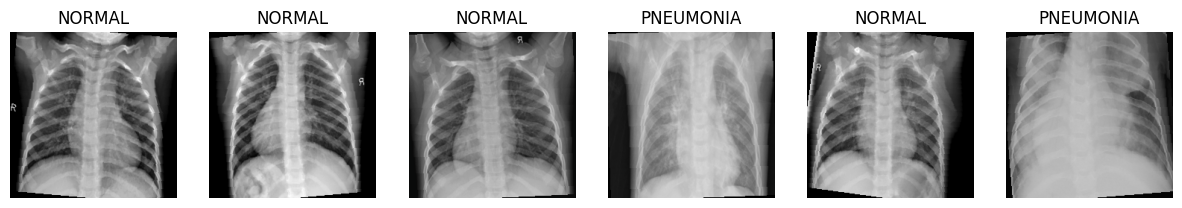

In [11]:
def denormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(denormalize(images[i]))
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")
plt.show()

In [12]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 28 -> 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(NUM_CLASSES).to(DEVICE)
print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds, all_probs


def run_experiment(model, train_loader, val_loader, num_epochs=10, lr=1e-4, weight_decay=1e-4,
                    experiment_name="experiment"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{experiment_name}] Epoch {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history

In [14]:
baseline_model, baseline_history = run_experiment(
    baseline_model, train_loader, val_loader,
    num_epochs=10, lr=1e-3, weight_decay=1e-4,
    experiment_name="baseline_cnn"
)

[baseline_cnn] Epoch 1/10 | train_loss=0.3811 train_acc=0.8360 | val_loss=0.1831 val_acc=0.9337
[baseline_cnn] Epoch 2/10 | train_loss=0.2755 train_acc=0.8903 | val_loss=0.1455 val_acc=0.9401
[baseline_cnn] Epoch 3/10 | train_loss=0.2298 train_acc=0.9109 | val_loss=0.7760 val_acc=0.7449
[baseline_cnn] Epoch 4/10 | train_loss=0.2276 train_acc=0.9102 | val_loss=0.2379 val_acc=0.9133
[baseline_cnn] Epoch 5/10 | train_loss=0.2030 train_acc=0.9206 | val_loss=0.3545 val_acc=0.8635
[baseline_cnn] Epoch 6/10 | train_loss=0.1735 train_acc=0.9375 | val_loss=0.6693 val_acc=0.7551
[baseline_cnn] Epoch 7/10 | train_loss=0.1695 train_acc=0.9389 | val_loss=0.1257 val_acc=0.9541
[baseline_cnn] Epoch 8/10 | train_loss=0.1657 train_acc=0.9389 | val_loss=0.1010 val_acc=0.9617
[baseline_cnn] Epoch 9/10 | train_loss=0.1438 train_acc=0.9483 | val_loss=0.0961 val_acc=0.9694
[baseline_cnn] Epoch 10/10 | train_loss=0.1374 train_acc=0.9508 | val_loss=0.2556 val_acc=0.9107


In [15]:
def build_resnet18(num_classes=2, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Replace final layer — always trainable
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

resnet_model = build_resnet18(NUM_CLASSES, freeze_backbone=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 36.8MB/s]


In [16]:
resnet_model, resnet_history = run_experiment(
    resnet_model, train_loader, val_loader,
    num_epochs=8, lr=1e-3, weight_decay=1e-4,
    experiment_name="resnet18_frozen"
)

[resnet18_frozen] Epoch 1/8 | train_loss=0.3491 train_acc=0.8574 | val_loss=0.3228 val_acc=0.8814
[resnet18_frozen] Epoch 2/8 | train_loss=0.2176 train_acc=0.9190 | val_loss=0.2148 val_acc=0.9171
[resnet18_frozen] Epoch 3/8 | train_loss=0.1944 train_acc=0.9273 | val_loss=0.1765 val_acc=0.9311
[resnet18_frozen] Epoch 4/8 | train_loss=0.1844 train_acc=0.9278 | val_loss=0.1909 val_acc=0.9286
[resnet18_frozen] Epoch 5/8 | train_loss=0.1931 train_acc=0.9237 | val_loss=0.2014 val_acc=0.9247
[resnet18_frozen] Epoch 6/8 | train_loss=0.1717 train_acc=0.9357 | val_loss=0.1716 val_acc=0.9298
[resnet18_frozen] Epoch 7/8 | train_loss=0.1763 train_acc=0.9341 | val_loss=0.2194 val_acc=0.9171
[resnet18_frozen] Epoch 8/8 | train_loss=0.1639 train_acc=0.9380 | val_loss=0.1783 val_acc=0.9286


In [17]:
for param in resnet_model.parameters():
    param.requires_grad = True

resnet_model, resnet_finetune_history = run_experiment(
    resnet_model, train_loader, val_loader,
    num_epochs=5, lr=1e-5, weight_decay=1e-4,
    experiment_name="resnet18_finetuned"
)

[resnet18_finetuned] Epoch 1/5 | train_loss=0.1129 train_acc=0.9592 | val_loss=0.0738 val_acc=0.9758
[resnet18_finetuned] Epoch 2/5 | train_loss=0.0780 train_acc=0.9700 | val_loss=0.0417 val_acc=0.9847
[resnet18_finetuned] Epoch 3/5 | train_loss=0.0675 train_acc=0.9754 | val_loss=0.0389 val_acc=0.9847
[resnet18_finetuned] Epoch 4/5 | train_loss=0.0559 train_acc=0.9788 | val_loss=0.0358 val_acc=0.9885
[resnet18_finetuned] Epoch 5/5 | train_loss=0.0597 train_acc=0.9781 | val_loss=0.0346 val_acc=0.9885


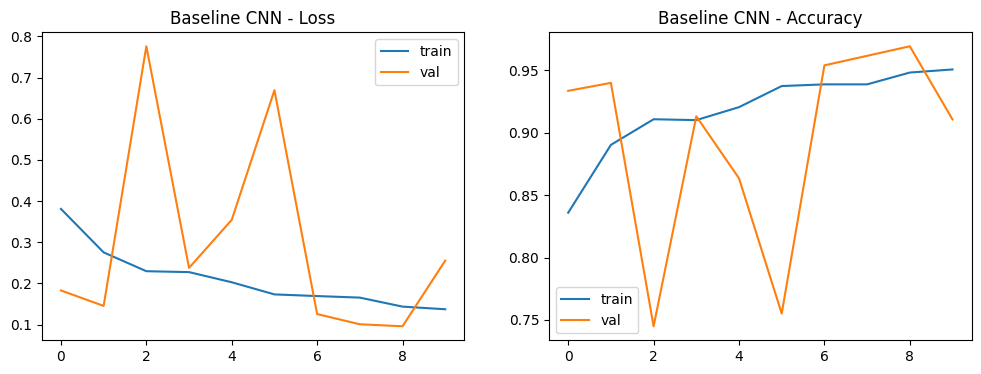

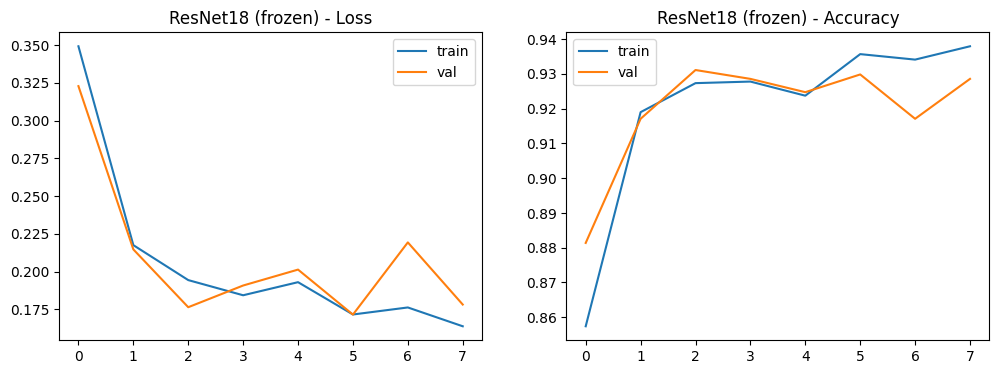

In [18]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].legend()
    plt.show()

plot_history(baseline_history, "Baseline CNN")
plot_history(resnet_history, "ResNet18 (frozen)")

=== Baseline CNN — Test Results ===
Test loss: 0.5217 | Test accuracy: 0.8317
ROC-AUC: 0.9328

              precision    recall  f1-score   support

      NORMAL       0.94      0.59      0.72       234
   PNEUMONIA       0.80      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.78      0.80       624
weighted avg       0.85      0.83      0.82       624



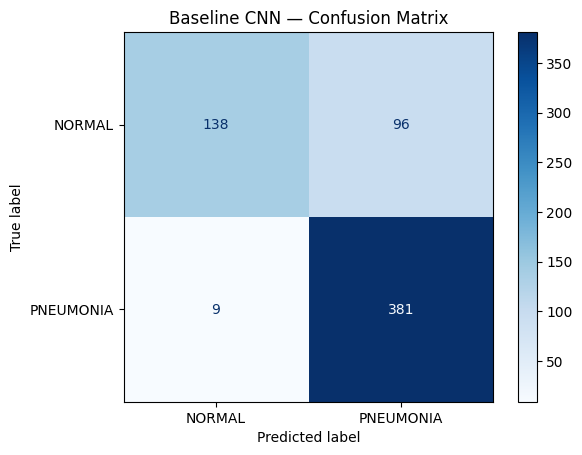

=== ResNet18 — Test Results ===
Test loss: 0.6151 | Test accuracy: 0.8381
ROC-AUC: 0.9592

              precision    recall  f1-score   support

      NORMAL       0.99      0.58      0.73       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



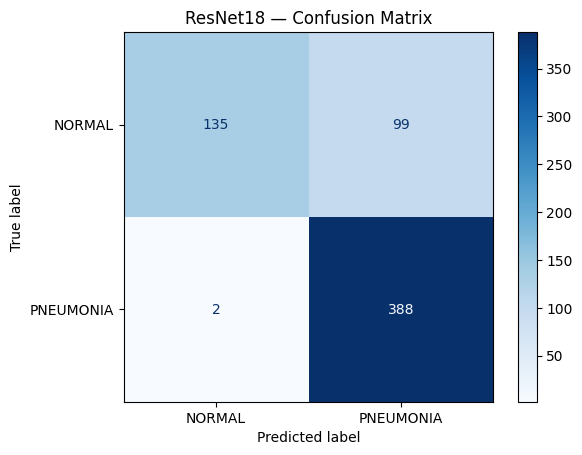

In [19]:
def full_test_report(model, test_loader, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, DEVICE)

    print(f"=== {model_name} — Test Results ===")
    print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

    return {"test_loss": test_loss, "test_acc": test_acc,
            "roc_auc": roc_auc_score(y_true, y_prob)}

baseline_results = full_test_report(baseline_model, test_loader, "Baseline CNN")
resnet_results = full_test_report(resnet_model, test_loader, "ResNet18")

In [20]:
comparison = pd.DataFrame([
    {"model": "Baseline CNN", **baseline_results},
    {"model": "ResNet18", **resnet_results},
])
comparison

,model,test_loss,test_acc,roc_auc
0,Baseline CNN,0.521674,0.831731,0.932774
1,ResNet18,0.615133,0.838141,0.959155


In [21]:
best_model, best_name = (
    (resnet_model, "resnet18") if resnet_results["roc_auc"] >= baseline_results["roc_auc"]
    else (baseline_model, "baseline_cnn")
)

checkpoint_path = CHECKPOINT_DIR / f"{best_name}_best.pth"
torch.save({
    "model_state_dict": best_model.state_dict(),
    "model_name": best_name,
    "img_size": IMG_SIZE,
    "class_names": CLASS_NAMES,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
}, checkpoint_path)

print(f"Saved best model ({best_name}) to {checkpoint_path}")

Saved best model (resnet18) to ../models/resnet18_best.pth
